# Workshop 3 — LRP and CRP

**Goal:** redistribute one selected score to pixels or intermediate channels.

**Flow:** basic rule → ResNet-18 → VGG-16 → CRP channels and targets.

**RTG 2767 version:** complete solution.


## Presenter path — about 45 minutes

1. **Say:** LRP redistributes one selected output score backward.
2. **Run:** the tiny linear example, then compare two ResNet targets.
3. **Compare:** ResNet-18 and VGG-16 using the same `carton` target.
4. **CRP:** inspect six channels, then hold channel 271 fixed and change target.

The notebook keeps the scientific choices visible. Architecture patching and
hook management live in `utils.lrp`.


## Run once — environment setup

Run the next cell; **do not present it**. In Google Colab it clones the small
public workshop repository and installs the additional dependencies. The first
run also downloads pretrained model weights and Imagenette.


In [1]:
import subprocess
import sys
from pathlib import Path

PUBLIC_REPOSITORY_URL = "https://github.com/erfanhatefi/rtg2767-xai-workshop.git"
PUBLIC_REPOSITORY_REF = "main"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPOSITORY_ROOT = Path("/content/rtg2767-xai-workshop")
    if not (REPOSITORY_ROOT / "utils").is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                PUBLIC_REPOSITORY_REF,
                PUBLIC_REPOSITORY_URL,
                str(REPOSITORY_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-r",
            str(REPOSITORY_ROOT / "requirements.txt"),
        ],
        check=True,
    )
else:
    candidates = (Path.cwd(), *Path.cwd().parents)
    REPOSITORY_ROOT = next(
        path for path in candidates if (path / "utils").is_dir()
    )

sys.path.insert(0, str(REPOSITORY_ROOT))
WORKSHOP_DATA_ROOT = REPOSITORY_ROOT / "workshop_data"
print("Setup complete.")

Setup complete.


## Before attributing: three labels that are easy to confuse

- **Dataset label:** what the dataset says is present in the image.
- **Top-1 prediction:** the output with the largest score for this input.
- **Explanation target:** the particular output score whose heatmap we request.

An ImageNet model has 1,000 output scores, indexed from 0 to 999. A heatmap is
always conditional on one selected output; it need not be the top-1 prediction.
In these notebooks we resolve targets by readable names and print the resulting
index: `carton` is index **478**, `French horn` is index **566**, and index **0**
is `tench`. The `carton` class means a cardboard carton/box. ImageNet-W adds a
watermark intended to raise that output—it does not claim that a carton is
actually visible in the photograph.


In [2]:
import time

import matplotlib.pyplot as plt
import torch
import torchvision

from utils import (
    explain_image,
    load_pretrained_resnet18,
    load_pretrained_vgg16,
    load_watermark_example,
    normalize_imagenet,
    plot_bwr_attributions,
    relevance_gap,
    resolve_imagenet_class_index,
    setup_lrp,
    show_image_grid,
)

SEED = 7
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Torchvision {torchvision.__version__} | {device}")

PyTorch 2.7.1+cu128 | Torchvision 0.22.1+cu128 | cuda


---
## 1. Basic LRP: redistribute a score

For lower-layer activation $a_i$, weight $w_{ij}$, and upper relevance $R_j$, the basic rule is

$$R_i=\sum_j \frac{a_iw_{ij}}{\sum_{i'}a_{i'}w_{i'j}}R_j.
$$

The fraction is neuron $i$'s share of the forward contribution to neuron $j$. The tiny example below contains only positive contributions and no bias, cancellation, or zero denominator.

In [3]:
def lrp_linear(activations, weights, output_relevance):
    """Redistribute relevance through one bias-free linear layer.

    Shapes are [input], [input, output], and [output], respectively.
    """
    # a_i w_ij is input i's forward contribution to output j.
    contributions = activations[:, None] * weights

    # Each output redistributes relevance in proportion to its contributions.
    contribution_sums = contributions.sum(dim=0)
    if torch.any(contribution_sums == 0):
        raise ValueError("Basic LRP is undefined for a zero contribution sum")

    relevance_messages = contributions / contribution_sums * output_relevance

    # Sum messages from all outputs to obtain one relevance per input.
    input_relevance = relevance_messages.sum(dim=1)
    return input_relevance, relevance_messages


activations = torch.tensor([2.0, 1.0])
weights = torch.tensor([[1.0], [1.0]])
output_relevance = torch.tensor([3.0])
input_relevance, relevance_messages = lrp_linear(
    activations,
    weights,
    output_relevance,
)

forward_contributions = (activations[:, None] * weights).squeeze()
print(f"Forward contributions : {forward_contributions.tolist()}")
print(f"Relevance messages    : {relevance_messages.squeeze().tolist()}")
print(f"Input relevance sum   : {input_relevance.sum().item():.1f}")
print(f"Output relevance sum  : {output_relevance.sum().item():.1f}")

Forward contributions : [2.0, 1.0]
Relevance messages    : [2.0, 1.0]
Input relevance sum   : 3.0
Output relevance sum  : 3.0


Real networks require explicit policies for small denominators, signed contributions, biases, nonlinearities, pooling, residual paths, and normalization. An $\epsilon$ stabilizer improves numerical behavior but can absorb relevance; exact conservation is therefore not guaranteed for every composite.

### Why implicit LRP works

LeXplaiNet replaces a module's backward behavior while preserving its ordinary forward value. One autograd backward pass then transports relevance, and `activation * modified_gradient` exposes that relevance. This is computationally close to a normal backward pass, but it is **not ordinary Gradient × Input** once the backward rules are patched.

---
## 2. ResNet-18: explain a learned watermark shortcut

The clean Imagenette image is a French horn. We apply the published ImageNet-W
text transform, select the `carton` logit, then canonize and patch ResNet-18.
The clean/watermarked pair tests the behavior; LRP redistributes the selected
watermarked score.

`setup_lrp(resnet_model, resnet=True)` performs two non-obvious steps:

1. **canonization:** fold BatchNorm parameters into adjacent convolutions while
   preserving the forward function;
2. **rule assignment:** replace ordinary backward behavior by the declared LRP
   redistribution rules.

Because explanations are meaningful only for the intended predictor, we verify
that setup does not change its logits or predicted class.


clean       prediction=French horn  p=99.94%  carton logit= -0.241
watermarked prediction=French horn  p=99.87%  carton logit= +4.016


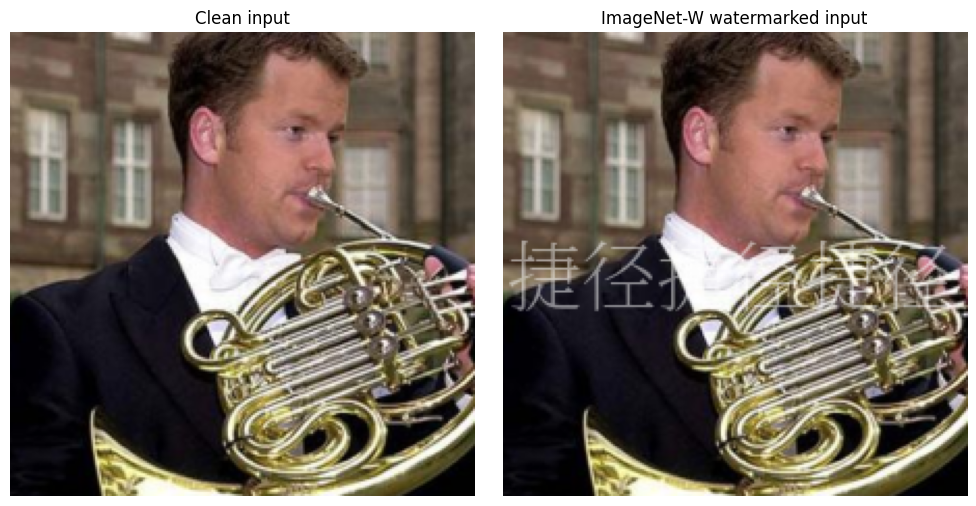

Available targets used below: 'carton' (index 478) and 'French horn' (index 566)


In [4]:
image_path, clean_display_image, display_image = load_watermark_example(
    WORKSHOP_DATA_ROOT,
    device,
)

resnet_model, resnet_class_names = load_pretrained_resnet18(device)
# Use names as the public interface; indices are only how the model stores outputs.
CARTON_TARGET_NAME = "carton"
INTENDED_OBJECT_NAME = "French horn"
carton_target_index = resolve_imagenet_class_index(CARTON_TARGET_NAME)
french_horn_target_index = resolve_imagenet_class_index(INTENDED_OBJECT_NAME)
resnet_target = carton_target_index
with torch.no_grad():
    clean_image_logits = resnet_model(normalize_imagenet(clean_display_image))[0]
    unpatched_resnet_logits = resnet_model(normalize_imagenet(display_image)).detach()

for label, logits in [
    ("clean", clean_image_logits),
    ("watermarked", unpatched_resnet_logits[0]),
]:
    probabilities = logits.softmax(dim=0)
    predicted_index = int(logits.argmax())
    print(
        f"{label:11s} prediction={resnet_class_names[predicted_index]:12s} "
        f"p={probabilities[predicted_index]:6.2%}  "
        f"carton logit={logits[resnet_target]:+7.3f}"
    )

show_image_grid(
    [clean_display_image, display_image],
    ["Clean input", "ImageNet-W watermarked input"],
)
print(
    f"Available targets used below: {CARTON_TARGET_NAME!r} "
    f"(index {carton_target_index}) and {INTENDED_OBJECT_NAME!r} "
    f"(index {french_horn_target_index})"
)

In [5]:
# Canonize ResNet and install the workshop LRP composite.
setup_lrp(resnet_model, resnet=True)

# Forward predictions should remain unchanged after explanation setup.
with torch.no_grad():
    patched_resnet_logits = resnet_model(
        normalize_imagenet(display_image)
    ).detach()

maximum_forward_difference = (
    unpatched_resnet_logits - patched_resnet_logits
).abs().max()
class_before_setup = int(unpatched_resnet_logits.argmax(dim=1))
class_after_setup = int(patched_resnet_logits.argmax(dim=1))

print(f"Maximum forward difference : {maximum_forward_difference.item():.3e}")
print(f"Predicted class preserved  : {class_before_setup == class_after_setup}")

Maximum forward difference : 9.403e-03
Predicted class preserved  : True


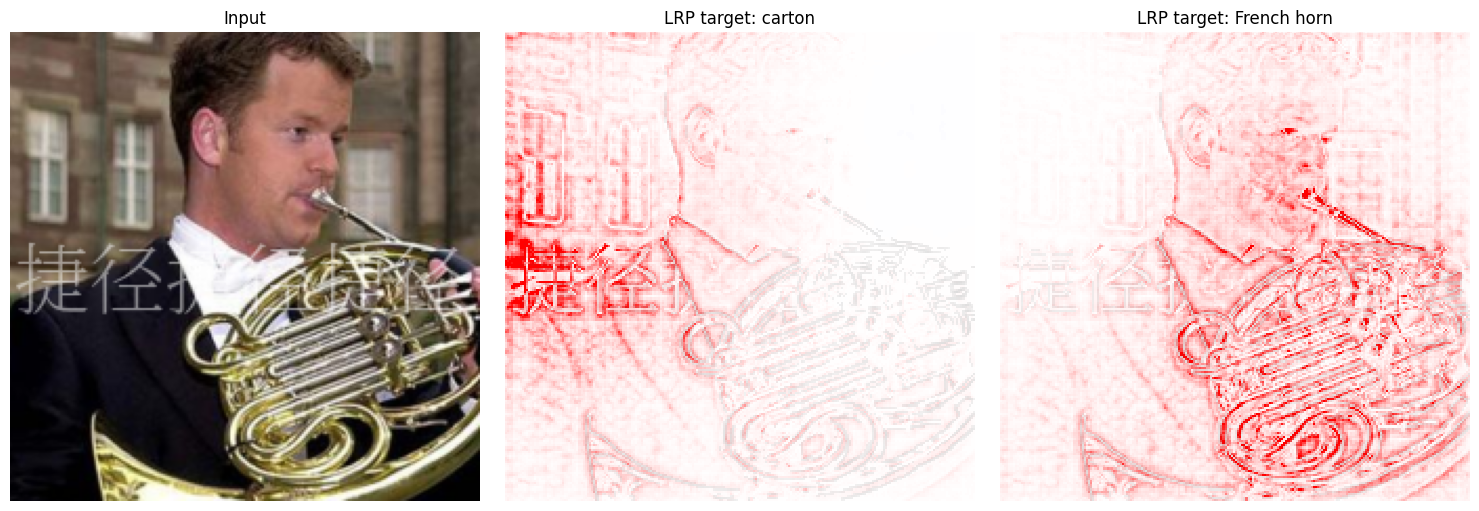

carton       score=+4.014  sum(R)=+4.014  gap=6.57e-05
French horn  score=+27.620  sum(R)=+27.620  gap=1.56e-05
Two target explanations: 0.04 seconds


In [6]:
resnet_start = time.perf_counter()

# The image is identical in both calls. Only the selected output score changes.
carton_result = explain_image(
    resnet_model,
    display_image,
    carton_target_index,
)
french_horn_result = explain_image(
    resnet_model,
    display_image,
    french_horn_target_index,
)
resnet_seconds = time.perf_counter() - resnet_start

# Each result stores the 2D signed heatmap, selected logit, and relevance sum.
# q=99.5 controls display clipping only; it does not alter conservation values.
plot_bwr_attributions(
    display_image,
    [
        carton_result["heatmap"],
        french_horn_result["heatmap"],
    ],
    [
        f"LRP target: {CARTON_TARGET_NAME}",
        f"LRP target: {INTENDED_OBJECT_NAME}",
    ],
    q=99.5,
)
for target_name, result in [
    (CARTON_TARGET_NAME, carton_result),
    (INTENDED_OBJECT_NAME, french_horn_result),
]:
    print(
        f"{target_name:12s} score={result['target_score']:+.3f}  "
        f"sum(R)={result['input_sum']:+.3f}  "
        f"gap={relevance_gap(result):.2e}"
    )
print(f"Two target explanations: {resnet_seconds:.2f} seconds")

Positive and negative relevance are evidence **for and against the selected logit under this composite**. They are not probabilities, causal effects, or object-segmentation labels. The conservation gap is a diagnostic of the chosen rules and numerical implementation; visual normalization must never be used for this check.

---
## 3. VGG-16: the same question, a different architecture

VGG-16 is sequential and has no BatchNorm, so it needs rule assignment but no
ResNet canonization. For a controlled comparison, image, preprocessing, LRP
rules, and `carton` target stay fixed; only the architecture changes.

The final convolutional ReLU, `features[29]`, has shape `[B, 512, 14, 14]`.
Its 512 channels are the candidate CRP concepts inspected next. A channel is a
learned feature coordinate—not automatically a human concept.


VGG-16 target: 'carton'
Forward difference: 0.00e+00
Conservation gap: 6.30e-05


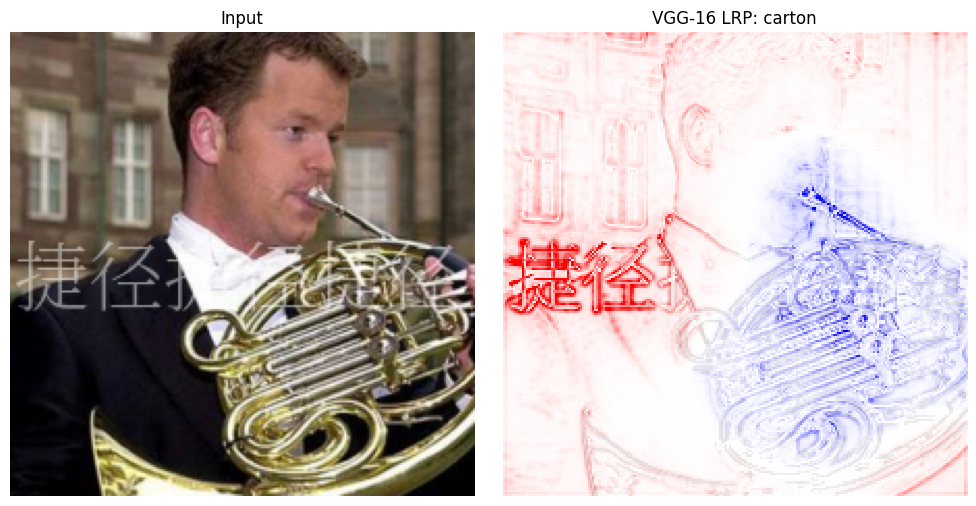

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Input'}>,
        <Axes: title={'center': 'VGG-16 LRP: carton'}>], dtype=object),
 [0.0014936742081772536])

In [7]:
# VGG-16 is large; release ResNet before loading it.
del resnet_model
if device.type == "cuda":
    torch.cuda.empty_cache()

vgg_model, vgg_class_names = load_pretrained_vgg16(device)
vgg_target_index = carton_target_index

# Record logits before patching so forward preservation can be checked.
with torch.no_grad():
    logits_before_lrp = vgg_model(normalize_imagenet(display_image)).detach()

setup_lrp(vgg_model)
with torch.no_grad():
    logits_after_lrp = vgg_model(normalize_imagenet(display_image)).detach()

# features[29] is the final convolutional ReLU: [1, 512, 14, 14].
concept_layer = vgg_model.features[29]
vgg_result = explain_image(
    vgg_model,
    display_image,
    vgg_target_index,
    layer=concept_layer,
)

print(f"VGG-16 target: {vgg_class_names[vgg_target_index]!r}")
print(f"Forward difference: {(logits_before_lrp - logits_after_lrp).abs().max():.2e}")
print(f"Conservation gap: {relevance_gap(vgg_result):.2e}")
# q affects visualization only, not the relevance values checked above.
plot_bwr_attributions(
    display_image,
    [vgg_result["heatmap"]],
    ["VGG-16 LRP: carton"],
    q=99.5,
)

---
## 4. Concept Relevance Propagation: condition the flow

Ordinary LRP combines relevance traveling through all hidden channels. CRP asks
a more specific question: **where does relevance flow if it must pass through
channel $c$ at layer $A$?**

For target $y$, the backward signal is masked as

$$R(x\mid y,c):\qquad
\widetilde{\nabla}_{A_k}s_y=0\quad\text{for }k\neq c.$$

The workflow has two steps:

1. rank channels by summed relevance for this image and the `carton` target;
2. propagate relevance separately through each of the six highest-ranked channels.

The ranking is local to this image, target, layer, model, and LRP composite.
Calling a channel “text” or “watermark” requires reference examples and ideally
an intervention; a high score alone does not establish its semantics.


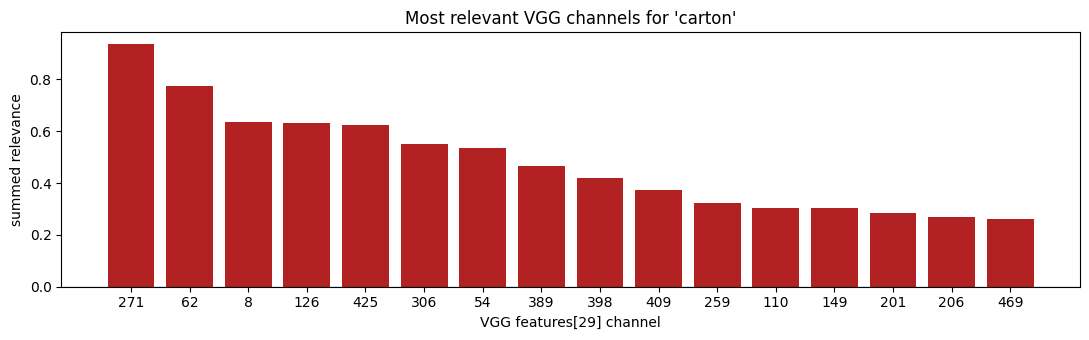

Selected channels: [271, 62, 8, 126, 425, 306]


In [8]:
# One signed score per channel, summed over its 14×14 spatial positions.
channel_scores = vgg_result["channel_scores"]

# Explain six channels, but display sixteen scores to show ranking context.
NUM_CHANNELS = 6
selected_scores, selected_channels = torch.topk(
    channel_scores,
    k=NUM_CHANNELS,
)
displayed_scores, displayed_channels = torch.topk(channel_scores, k=16)
bar_colors = [
    "firebrick" if score >= 0 else "royalblue"
    for score in displayed_scores
]

figure, axis = plt.subplots(figsize=(11, 3.5))
axis.bar(
    [str(int(channel)) for channel in displayed_channels],
    displayed_scores.numpy(),
    color=bar_colors,
)
axis.axhline(0.0, color="black", linewidth=0.8)
axis.set_xlabel("VGG features[29] channel")
axis.set_ylabel("summed relevance")
axis.set_title("Most relevant VGG channels for 'carton'")
figure.tight_layout()
plt.show()

print("Selected channels:", [int(channel) for channel in selected_channels])

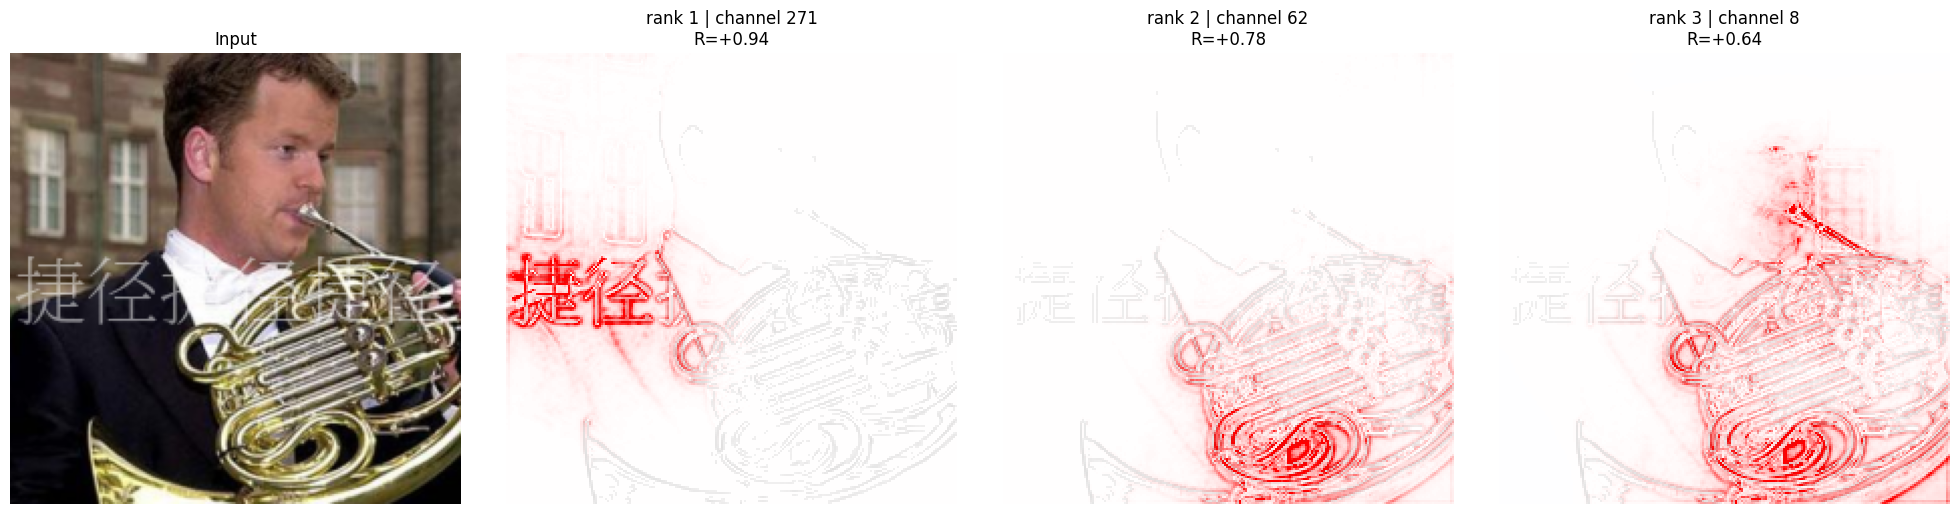

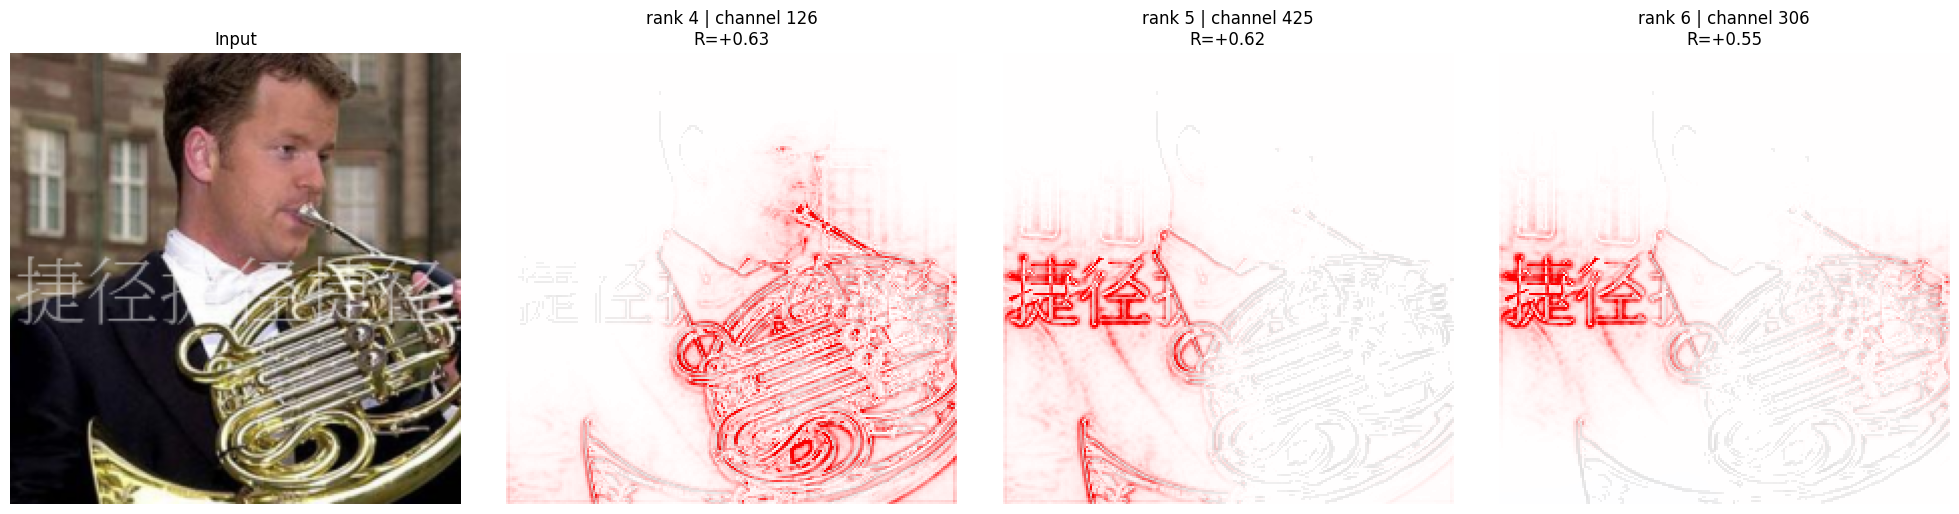

6 channel explanations: 0.42s


In [9]:
crp_start = time.perf_counter()
conditional_heatmaps = []
conditional_titles = []

# Every pass starts from the same carton score and keeps one channel's relevance.
for rank, (channel, score) in enumerate(
    zip(selected_channels, selected_scores),
    start=1,
):
    channel = int(channel)
    channel_result = explain_image(
        vgg_model,
        display_image,
        vgg_target_index,
        layer=concept_layer,
        channel=channel,
    )
    conditional_heatmaps.append(channel_result["heatmap"])
    conditional_titles.append(
        f"rank {rank} | channel {channel}\nR={float(score):+.2f}"
    )

# Show three maps per row so individual spatial patterns remain readable.
for start in range(0, len(conditional_heatmaps), 3):
    plot_bwr_attributions(
        display_image,
        conditional_heatmaps[start : start + 3],
        conditional_titles[start : start + 3],
        q=99.5,
    )

elapsed = time.perf_counter() - crp_start
print(f"{NUM_CHANNELS} channel explanations: {elapsed:.2f}s")

Each conditional map answers: **where does
relevance for this target flow when it is constrained to this channel?**

Use the six maps to investigate three questions:

1. **Localization:** does a channel focus on the watermark, the horn, its edges,
   or broad background regions?
2. **Diversity:** do different channels route relevance through different
   regions, or do several emphasize the same evidence?
3. **Specificity:** would the same channel remain highly relevant for the clean
   image or the `French horn` target? That comparison is a useful extension.

A high ranking does not give a channel a semantic name, and similar maps do not
prove identical concepts. Full CRP commonly adds Relevance Maximization
(RelMax): rank a reference collection by channel relevance, inspect maximally
activating/relevant examples, propose a semantic interpretation, and then test
that interpretation with interventions.


---
## 5. One channel does not have one target-independent explanation

CRP conditions on both a hidden channel **and** an output target. To make that
dependence visible, we hold the image, VGG-16, `features[29]`, and channel 271
fixed. We change only the explained logit from `carton` to `French horn`.

If the heatmaps differ, this is expected: channel 271 can participate in the
two output computations through different downstream relevance paths. A
channel therefore should not be assigned one universal heatmap or semantic
meaning without specifying the target.


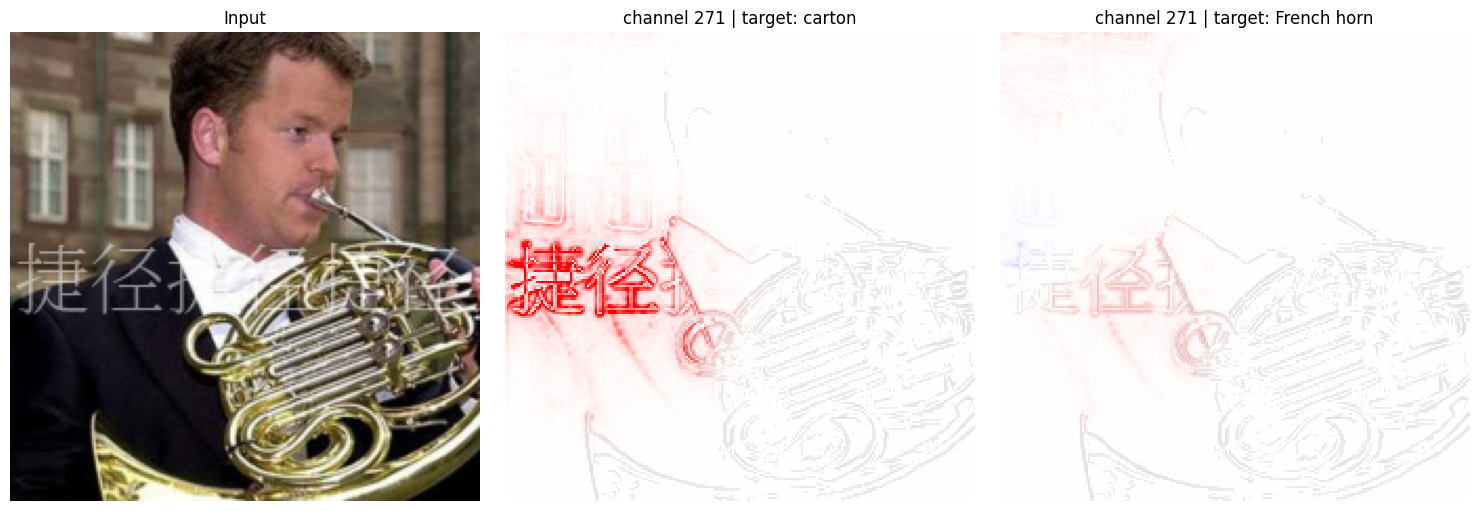

Heatmaps numerically identical: False
carton       | sum(R)=+0.935 | sum(|R|)=0.935
French horn  | sum(R)=+0.175 | sum(|R|)=0.196


In [10]:
COMPARISON_CHANNEL = 271

# Everything is fixed except the selected output logit.
carton_channel_result = explain_image(
    vgg_model,
    display_image,
    carton_target_index,
    layer=concept_layer,
    channel=COMPARISON_CHANNEL,
)
french_horn_channel_result = explain_image(
    vgg_model,
    display_image,
    french_horn_target_index,
    layer=concept_layer,
    channel=COMPARISON_CHANNEL,
)

# A shared color scale preserves magnitude differences between the two maps.
plot_bwr_attributions(
    display_image,
    [
        carton_channel_result["heatmap"],
        french_horn_channel_result["heatmap"],
    ],
    [
        f"channel {COMPARISON_CHANNEL} | target: carton",
        f"channel {COMPARISON_CHANNEL} | target: French horn",
    ],
    q=99.5,
    shared_scale=True,
)

maps_are_identical = torch.allclose(
    carton_channel_result["heatmap"],
    french_horn_channel_result["heatmap"],
)
print(f"Heatmaps numerically identical: {maps_are_identical}")

for target_name, channel_result in [
    (CARTON_TARGET_NAME, carton_channel_result),
    (INTENDED_OBJECT_NAME, french_horn_channel_result),
]:
    absolute_relevance = channel_result["heatmap"].abs().sum()
    print(
        f"{target_name:12s} | sum(R)={channel_result['input_sum']:+.3f} "
        f"| sum(|R|)={absolute_relevance:.3f}"
    )

---
## Take-home checklist

| Component | Report explicitly | Main caution |
|---|---|---|
| LRP target | model, checkpoint, preprocessing, selected logit | relevance is target-specific |
| Composite | rule per module, stabilizers, bias policy | “LRP” is not one unique algorithm |
| Architecture | canonization, residual/pooling/normalization handling | equivalent graphs can explain differently |
| Aggregation | RGB or embedding reduction | aggregation changes the displayed object |
| CRP | target, layer, channel mask, channel ranking | a channel is not automatically a human concept |
| Visualization | sign convention, clipping, normalization | colors are not cross-map magnitudes |

### References

- Bach et al. (2015), [On Pixel-Wise Explanations for Non-Linear Classifier Decisions by Layer-Wise Relevance Propagation](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0130140)
- Montavon et al. (2019), [Layer-Wise Relevance Propagation: An Overview](https://doi.org/10.1007/978-3-030-28954-6_10)
- Pahde et al. (2023), [Optimizing Explanations by Network Canonization and Hyperparameter Search](https://openaccess.thecvf.com/content/CVPR2023W/SAIAD/html/Pahde_Optimizing_Explanations_by_Network_Canonization_and_Hyperparameter_Search_CVPRW_2023_paper.html)
- Achtibat et al. (2023), [From Attribution Maps to Human-Understandable Explanations through Concept Relevance Propagation](https://www.nature.com/articles/s42256-023-00711-8)
- Achtibat et al. (2024), [AttnLRP: Attention-Aware Layer-Wise Relevance Propagation for Transformers](https://arxiv.org/abs/2402.05602)